In [2]:
import pandas as pd
import sys
import numpy as np

print("Pandas kütüphanesi içe aktarıldı.")
print("-" * 30)

# 1. Dosya yolunuz
yerel_dosya_yolu = "clean_data.csv"

try:
    print(f"'{yerel_dosya_yolu}' yerel dosyasından veri seti yükleniyor...")
    df = pd.read_csv(yerel_dosya_yolu)
    print("Veri seti yüklendi.")
    print(f"Orijinal veri boyutu (6 Sınıf): {df.shape}")

    # 2. SÜTUN KONTROLÜ
    if 'clean_content' in df.columns and 'label' in df.columns:
        print("'clean_content' sütunu 'text' olarak yeniden adlandırılıyor...")
        df.rename(columns={'clean_content': 'text'}, inplace=True)
    elif 'text' not in df.columns or 'label' not in df.columns:
        raise ValueError("Gerekli 'text'/'clean_content' veya 'label' sütunları bulunamadı.")

    print("-" * 30)

    # 3. Veriyi Kontrol Et
    print("\nEtiket (label) sütunu değerleri ve sayıları (Tüm 6 Sınıf):")
    print(df['label'].value_counts().sort_index())

except Exception as e:
    print(f"\n\nHATA: Veri seti yüklenirken bir sorun oluştu: {e}")
    sys.exit(1)

Pandas kütüphanesi içe aktarıldı.
------------------------------
'clean_data.csv' yerel dosyasından veri seti yükleniyor...
Veri seti yüklendi.
Orijinal veri boyutu (6 Sınıf): (136124, 2)
'clean_content' sütunu 'text' olarak yeniden adlandırılıyor...
------------------------------

Etiket (label) sütunu değerleri ve sayıları (Tüm 6 Sınıf):
label
Emotion      28308
Financial    22979
Health       36352
Politics     37778
Science       4634
Sport         6073
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from collections import Counter

# 1. Özellik (X) ve Hedef (y) Belirleme
# (NaN hatasını önlemek için .fillna('') ekli)
X = df['text'].fillna('')
y = df['label']

# 2. Veriyi Eğitim ve Test Setlerine Ayırma
# stratify=y, 6 sınıfın oranını koruyarak bölecek
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# 3. Sonuçları Kontrol Etme
print("Veri Ayırma Sonuçları (6 Sınıf):")
print(f"Eğitim Seti (X_train) Boyutu: {len(X_train)}")
print(f"Test Seti (X_test) Boyutu: {len(X_test)}")
print("\nEğitim Seti Sınıf Dağılımı (y_train):")
print(Counter(y_train))

Veri Ayırma Sonuçları (6 Sınıf):
Eğitim Seti (X_train) Boyutu: 108899
Test Seti (X_test) Boyutu: 27225

Eğitim Seti Sınıf Dağılımı (y_train):
Counter({'Politics': 30222, 'Health': 29082, 'Emotion': 22646, 'Financial': 18383, 'Sport': 4859, 'Science': 3707})


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. TF-IDF Vektörleştiricisini Tanımlama
tfidf_vectorizer = TfidfVectorizer(stop_words='english',
                                     ngram_range=(1, 2),
                                     max_features=20000)

print("TF-IDF Vektörleştiricisi (n-gram ile) oluşturuldu.")
print("Eğitim verisi üzerinde 'fit' ve 'transform' işlemi başlıyor...")

# 2. Eğitim Verisini Vektörleştirme
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print("Eğitim verisi dönüştürüldü.")
print("Test verisi üzerinde 'transform' işlemi başlıyor...")

# 3. Test Verisini Vektörleştirme
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Test verisi dönüştürüldü.")
print("\n" + "-" * 30 + "\n")

# 4. Sonuçların Boyutlarını Kontrol Etme
print("Oluşturulan TF-IDF Matrislerinin Boyutları:")
print(f"Eğitim Seti (X_train_tfidf) Boyutu: {X_train_tfidf.shape}")
print(f"Test Seti (X_test_tfidf) Boyutu: {X_test_tfidf.shape}")

TF-IDF Vektörleştiricisi (n-gram ile) oluşturuldu.
Eğitim verisi üzerinde 'fit' ve 'transform' işlemi başlıyor...
Eğitim verisi dönüştürüldü.
Test verisi üzerinde 'transform' işlemi başlıyor...
Test verisi dönüştürüldü.

------------------------------

Oluşturulan TF-IDF Matrislerinin Boyutları:
Eğitim Seti (X_train_tfidf) Boyutu: (108899, 20000)
Test Seti (X_test_tfidf) Boyutu: (27225, 20000)


In [5]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# 1. Parametre Izgarası (SVM için 'C' parametresi)
param_grid = {
    'C': [0.1, 0.5, 1, 5, 10]
}

# 2. GridSearchCV Aracını Kurma
# dual=False ve max_iter=2000 ayarları performansı artırır
grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=42, dual=False, max_iter=2000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2  # İşlemin ilerleyişini gösterir
)

print("GridSearchCV ile en iyi 'C' değeri SVM için aranıyor (6 Sınıf)...")
print(f"Denenecek parametreler: {param_grid['C']}")
print(f"Yapılacak toplam eğitim (fit) sayısı: {len(param_grid['C']) * 5}")
print("\n" + "="*30)
print("UYARI: Bu işlem MultinomialNB'den ÇOK DAHA UZUN sürecektir.")
print("6 Sınıf ile bu süre 15-30+ dakika sürebilir. Lütfen sabırlı olun.")
print("="*30 + "\n")

# 3. Modeli Fit Etme (Eğitme)
grid_search.fit(X_train_tfidf, y_train)

# 4. En İyi Sonuçları Gösterme
print("\n" + "-"*30)
print("Hiperparametre ayarı tamamlandı.")
print(f"Bulunan en iyi 'C' değeri: {grid_search.best_params_}")
print(f"Bu parametre ile elde edilen en iyi ortalama Cross-Validation skoru: {grid_search.best_score_:.4f}")
print("-"*30 + "\n")

# 5. En iyi modeli 'best_model' olarak kaydetme
best_model = grid_search.best_estimator_

print("En iyi 6-Sınıf SVM modeli 'best_model' değişkenine kaydedildi.")

GridSearchCV ile en iyi 'C' değeri SVM için aranıyor (6 Sınıf)...
Denenecek parametreler: [0.1, 0.5, 1, 5, 10]
Yapılacak toplam eğitim (fit) sayısı: 25

UYARI: Bu işlem MultinomialNB'den ÇOK DAHA UZUN sürecektir.
6 Sınıf ile bu süre 15-30+ dakika sürebilir. Lütfen sabırlı olun.

Fitting 5 folds for each of 5 candidates, totalling 25 fits


KeyboardInterrupt: 

En iyi 6-Sınıf SVM modeli (C=0.5) test verisi üzerinde değerlendiriliyor...
Tahmin işlemi tamamlandı.


Model Performans Raporu:
Genel Doğruluk (Accuracy): 0.9046 (Yani tahminlerin %90.46'si doğru)

--------------------------------------------------

Detaylı Sınıflandırma Raporu (6 Sınıf - SVM):
              precision    recall  f1-score   support

     Emotion       0.91      0.93      0.92      5662
   Financial       0.92      0.88      0.90      4596
      Health       0.88      0.91      0.90      7270
    Politics       0.93      0.94      0.93      7556
     Science       0.77      0.53      0.63       927
       Sport       0.91      0.87      0.89      1214

    accuracy                           0.90     27225
   macro avg       0.89      0.84      0.86     27225
weighted avg       0.90      0.90      0.90     27225


--------------------------------------------------

Karmaşıklık Matrisi (6 Sınıf - SVM):


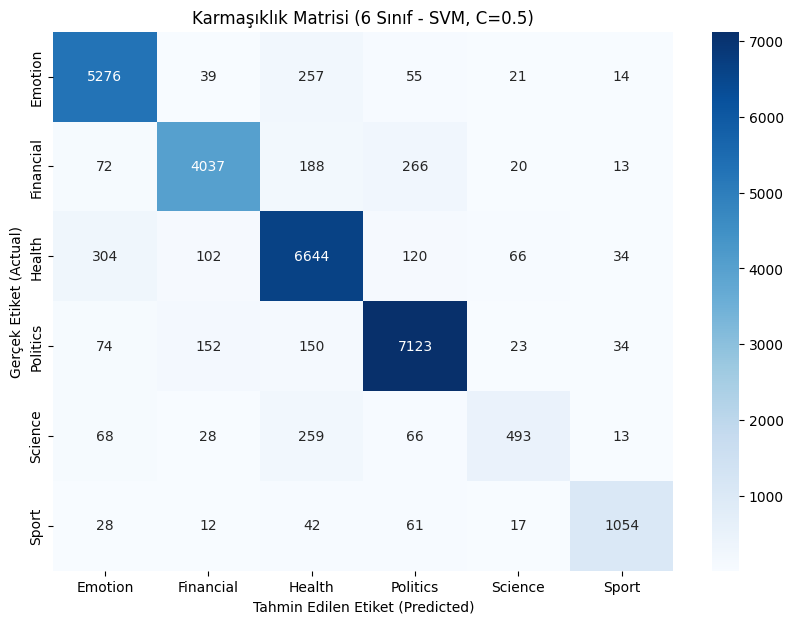

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(f"En iyi 6-Sınıf SVM modeli (C={best_model.C}) test verisi üzerinde değerlendiriliyor...")

# 1. Test seti üzerinde tahmin yapma
y_pred = best_model.predict(X_test_tfidf)

print("Tahmin işlemi tamamlandı.")
print("\n" + "="*50 + "\n")


# 2. Genel Doğruluk (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print("Model Performans Raporu:")
print(f"Genel Doğruluk (Accuracy): {accuracy:.4f} (Yani tahminlerin %{accuracy*100:.2f}'si doğru)")
print("\n" + "-"*50 + "\n")


# 3. Detaylı Sınıflandırma Raporu
print("Detaylı Sınıflandırma Raporu (6 Sınıf - SVM):")
print(classification_report(y_test, y_pred))
print("\n" + "-"*50 + "\n")


# 4. Karmaşıklık Matrisi (Confusion Matrix)
print("Karmaşıklık Matrisi (6 Sınıf - SVM):")

labels = best_model.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels)

# Heatmap artık 6x6 olacak
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Tahmin Edilen Etiket (Predicted)')
plt.ylabel('Gerçek Etiket (Actual)')
plt.title(f'Karmaşıklık Matrisi (6 Sınıf - SVM, C={best_model.C})')
plt.show()